# BINNs: Biologically-Informed Neural Networks
### SIAM Life Sciences 2026 — Deep Learning Part 2, Example 2

---

**Where we are in Part 2:**

| Strategy | Notebook | Key idea |
|---|---|---|
| Mechanistic | Example 0 | A neuron *is* logistic regression |
| Attribution | Example 1 | Grad-CAM shows *where* the model looked |
| **Structural embedding** | **Example 2 (this)** | **Embed known biology; learn what you don't know** |

---

**The biological scenario:**
You believe you have a predator-prey system — Lotka-Volterra — but you don't know the parameters.
You have a short, noisy time series. How do you recover $\alpha, \beta, \gamma, \delta$?

**The BINN answer:** Build a neural network that approximates the trajectory $(x(t), y(t))$
and train it with two losses:
1. **Data loss** — fit the noisy observations.
2. **Biology loss** — the network's output must satisfy the Lotka-Volterra equations.

The biological parameters are *learnable variables* alongside the network weights.
At the end of training you read off $\hat{\alpha}, \hat{\beta}, \hat{\gamma}, \hat{\delta}$ directly.

**Key advantage over derivative-based methods:**
We use automatic differentiation to compute $\frac{d}{dt}[\text{network}(t)]$ exactly.
No Savitzky-Golay smoothing. No noise amplification in the derivative.


## 1. Setup


In [11]:
import numpy as np
import tensorflow as tf
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print('TensorFlow:', tf.__version__)
print('GPU available:', len(tf.config.list_physical_devices('GPU')) > 0)


TensorFlow: 2.20.0
GPU available: False


## 2. Lotka-Volterra Data

The true predator-prey equations are:
$$\dot{x} = \alpha x - \beta xy \qquad \text{(prey grows, predation removes)}$$
$$\dot{y} = \gamma xy - \delta y \qquad \text{(predation converts, predator dies)}$$

True parameters: $\alpha=1.0,\ \beta=0.1,\ \gamma=0.075,\ \delta=1.5$.

We observe a **noisy, short** time series. `NOISE_LEVEL` is tunable — try 0.0, 0.10, 0.30.


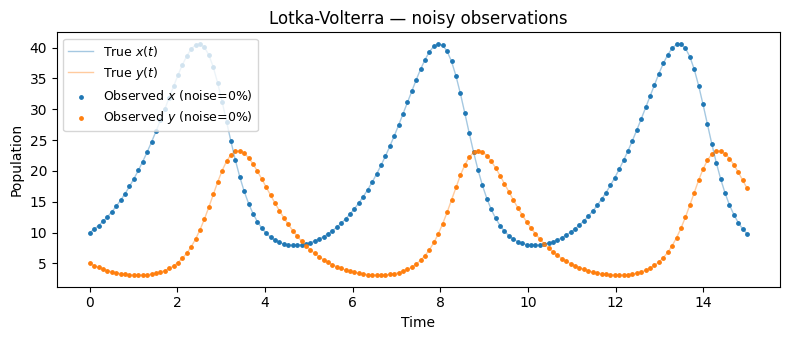

In [13]:
# ── True parameters ───────────────────────────────────────────────────────────
ALPHA_TRUE = 1.00   # prey growth rate
BETA_TRUE  = 0.10   # predation rate
GAMMA_TRUE = 0.075  # conversion efficiency
DELTA_TRUE = 1.50   # predator death rate
x0 = [18.0, 9.0]   # initial conditions — near LV equilibrium (x*=20, y*=10)
                    # Starting close to equilibrium gives moderate oscillations
                    # the network can learn; large-amplitude ICs (e.g. [10,5])
                    # produce swings so wide that Phase 1 stalls in a local minimum.

# ── Tunable noise ──────────────────────────────────────────────────────────────
NOISE_LEVEL = 0.0   # fraction of signal std; try 0.0, 0.10, 0.30

# ── Integrate true ODE ────────────────────────────────────────────────────────
t_obs = np.linspace(0, 15, 150)

def true_ode(t, z):
    x, y = z
    return [ALPHA_TRUE*x - BETA_TRUE*x*y,
            GAMMA_TRUE*x*y - DELTA_TRUE*y]

sol = solve_ivp(true_ode, [0, 15], x0, t_eval=t_obs, max_step=0.05)
x_clean, y_clean = sol.y[0], sol.y[1]

np.random.seed(7)
x_data = x_clean + NOISE_LEVEL * np.std(x_clean) * np.random.randn(len(t_obs))
y_data = y_clean + NOISE_LEVEL * np.std(y_clean) * np.random.randn(len(t_obs))

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(t_obs, x_clean, 'C0-', lw=1, alpha=0.4, label='True $x(t)$')
ax.plot(t_obs, y_clean, 'C1-', lw=1, alpha=0.4, label='True $y(t)$')
ax.scatter(t_obs, x_data, s=6, c='C0', label=f'Observed $x$ (noise={NOISE_LEVEL:.0%})')
ax.scatter(t_obs, y_data, s=6, c='C1', label=f'Observed $y$ (noise={NOISE_LEVEL:.0%})')
ax.set(xlabel='Time', ylabel='Population', title='Lotka-Volterra — noisy observations')
ax.legend(fontsize=9); plt.tight_layout(); plt.show()


## 3. The BINN Architecture

We train a small feed-forward network:
$$\mathcal{N}_{\theta} : t \mapsto \begin{pmatrix} \hat{x}(t) \\ \hat{y}(t) \end{pmatrix}$$

with 3 hidden layers of 32 units and $\tanh$ activations.

Alongside the network weights $\theta$, we learn **four biological parameters**
as unconstrained scalars in log-space (to enforce positivity):
$$\log\alpha,\ \log\beta,\ \log\gamma,\ \log\delta \in \mathbb{R}$$

All 12 + 4 = parameters are updated jointly by Adam.

**Why $\tanh$?** Unlike ReLU, $\tanh$ is smooth and its derivative is well-defined everywhere —
important because we will differentiate the network output with respect to its input $t$.


In [14]:
class LotkaVolterraBINN(tf.keras.Model):
    """
    Biologically-Informed Neural Network for Lotka-Volterra parameter recovery.

    The network N(t) approximates (x(t), y(t)).
    Layers are stored individually (NOT as tf.keras.Sequential) so that
    tf.GradientTape can trace gradients through the network w.r.t. time input t.
    Using Sequential with input_shape creates a hidden InputLayer that breaks
    the gradient tape trace — a known TF2 PINN gotcha.
    """
    def __init__(self, hidden_units=32, n_layers=3):
        super().__init__()
        # ── Individual Dense layers (tanh) ─────────────────────────────────
        self.hidden_layers = [tf.keras.layers.Dense(hidden_units, activation='tanh')
                              for _ in range(n_layers)]
        self.out_layer = tf.keras.layers.Dense(2)   # linear output: (x, y)

        # ── Learnable biological parameters (log-scale → always positive) ─
        # IMPORTANT: use tf.keras.Variable, NOT tf.Variable.
        # Keras 3 only tracks tf.keras.Variable in model.trainable_variables.
        # Plain tf.Variable attributes are silently ignored — parameters
        # appear to exist but never receive gradient updates.
        init = float(tf.math.log(0.5))   # starting guess: all params = 0.5
        self.log_alpha = tf.keras.Variable(init, name='log_alpha', dtype=tf.float32)
        self.log_beta  = tf.keras.Variable(init, name='log_beta',  dtype=tf.float32)
        self.log_gamma = tf.keras.Variable(init, name='log_gamma', dtype=tf.float32)
        self.log_delta = tf.keras.Variable(init, name='log_delta', dtype=tf.float32)

    @property
    def alpha(self): return tf.exp(self.log_alpha)
    @property
    def beta(self):  return tf.exp(self.log_beta)
    @property
    def gamma(self): return tf.exp(self.log_gamma)
    @property
    def delta(self): return tf.exp(self.log_delta)

    def call(self, t):
        """Forward pass: t (N,1) → (x(t), y(t)) (N,2)"""
        h = t
        for layer in self.hidden_layers:
            h = layer(h)
        return self.out_layer(h)


# Build model and check
model = LotkaVolterraBINN()
_ = model(tf.constant([[0.0]]))   # trigger weight creation
print(f'Network weights: {sum(tf.size(v).numpy() for v in model.trainable_variables)} total parameters')
print(f'\nInitial parameter guesses:')
print(f'  alpha = {float(model.alpha):.3f}  (true {ALPHA_TRUE})')
print(f'  beta  = {float(model.beta):.3f}  (true {BETA_TRUE})')
print(f'  gamma = {float(model.gamma):.3f}  (true {GAMMA_TRUE})')
print(f'  delta = {float(model.delta):.3f}  (true {DELTA_TRUE})')


Network weights: 2246 total parameters

Initial parameter guesses:
  alpha = 0.500  (true 1.0)
  beta  = 0.500  (true 0.1)
  gamma = 0.500  (true 0.075)
  delta = 0.500  (true 1.5)


## 4. The Two-Part Loss

### Data loss
Fit the noisy observations at times $t_1, \ldots, t_N$:
$$\mathcal{L}_{\text{data}} = \frac{1}{N}\sum_{i=1}^N
\bigl[(\hat{x}(t_i)-x_i^{\text{obs}})^2 + (\hat{y}(t_i)-y_i^{\text{obs}})^2\bigr]$$

### Biology loss
At a dense set of *collocation points* $\{\tau_j\}$, enforce the Lotka-Volterra equations:
$$\mathcal{L}_{\text{bio}} = \frac{1}{M}\sum_{j=1}^M
\left[\left(\frac{d\hat{x}}{dt}\bigg|_{\tau_j} - \alpha\hat{x}_j + \beta\hat{x}_j\hat{y}_j\right)^2
+\left(\frac{d\hat{y}}{dt}\bigg|_{\tau_j} - \gamma\hat{x}_j\hat{y}_j + \delta\hat{y}_j\right)^2\right]$$

The derivative $\frac{d\hat{x}}{dt}$ is computed via **automatic differentiation** (not finite differences):
$$\frac{d}{dt}\mathcal{N}_\theta(t) = J_\theta(t) \qquad \text{(exact, using `tf.GradientTape`)}$$

### Initial condition loss
The initial state is known: $(x(0), y(0)) = (x_0^{(1)}, x_0^{(2)})$ (set in the data cell).
$$\mathcal{L}_{\text{ic}} = (\hat{x}(0) - x_0^{(1)})^2 + (\hat{y}(0) - x_0^{(2)})^2$$

### Total loss
$$\mathcal{L} = \mathcal{L}_{\text{data}} + \lambda_{\text{bio}}\,\mathcal{L}_{\text{bio}}
+ \lambda_{\text{ic}}\,\mathcal{L}_{\text{ic}}$$

We train in **two phases**:
- Phase 1 ($\lambda_{\text{bio}}=0$): network learns the rough shape of the trajectory from data alone.
- Phase 2 ($\lambda_{\text{bio}}>0$): physics kicks in, parameter estimates converge.


In [15]:
# ── Prepare tensors ───────────────────────────────────────────────────────────
t_obs_tf  = tf.constant(t_obs.reshape(-1,1),  dtype=tf.float32)
xy_obs_tf = tf.constant(np.column_stack([x_data, y_data]), dtype=tf.float32)
ic_tf     = tf.constant([[x0[0], x0[1]]], dtype=tf.float32)

# Collocation points: denser grid on [0, 15] for physics enforcement.
# Stored as a numpy array — we create a fresh tf.constant inside each
# train_step call.  Do NOT use tf.Variable here: watching a Variable
# inside a *nested* GradientTape returns None in TF2 (confirmed bug).
N_COLLOC      = 400
t_colloc_np   = np.linspace(0, 15, N_COLLOC).reshape(-1, 1).astype(np.float32)

# ── Training step ─────────────────────────────────────────────────────────────
def train_step(model, opt_net, opt_bio, lam_bio, lam_ic):
    """One Adam step.
    Uses separate optimizers for network weights (opt_net) and biological
    parameters (opt_bio).  Giving bio params a lower learning rate prevents
    them from overshooting while the network is still fitting the trajectory.
    Returns (data_loss, bio_loss, ic_loss) as Python floats.
    """
    with tf.GradientTape() as outer:
        # ── Data loss: fit observations ────────────────────────────────────
        xy_pred   = model(t_obs_tf)
        data_loss = tf.reduce_mean(tf.square(xy_pred - xy_obs_tf))

        # ── IC loss: pin known initial condition ───────────────────────────
        xy_ic   = model(tf.constant([[0.0]]))
        ic_loss = tf.reduce_mean(tf.square(xy_ic - ic_tf))

        # ── Biology loss: enforce LV equations via autodiff ────────────────
        # TF2 gotcha: watching a tf.Variable inside a nested GradientTape
        # returns None — the outer tape breaks the inner gradient path.
        # Fix: create a plain EagerTensor with tf.constant, then watch it.
        with tf.GradientTape(persistent=True) as inner:
            t_c  = tf.constant(t_colloc_np)  # plain tensor — safe to watch
            inner.watch(t_c)
            xy_c = model(t_c)                # (N_COLLOC, 2)
            x_c  = xy_c[:, 0:1]
            y_c  = xy_c[:, 1:2]

        # Exact time derivatives via chain rule through the network
        dxdt = inner.gradient(x_c, t_c)     # (N_COLLOC, 1)
        dydt = inner.gradient(y_c, t_c)
        del inner

        # LV residuals — should be zero if the ODE is exactly satisfied
        res_x = dxdt - (model.alpha * x_c - model.beta  * x_c * y_c)
        res_y = dydt - (model.gamma * x_c * y_c - model.delta * y_c)
        bio_loss = tf.reduce_mean(tf.square(res_x)) + tf.reduce_mean(tf.square(res_y))

        total = data_loss + lam_bio * bio_loss + lam_ic * ic_loss

    # ── Apply gradients with separate optimizers ───────────────────────────
    # Split variables: Dense layer weights vs biological log-parameters
    net_vars = [v for v in model.trainable_variables if 'log_' not in v.name]
    bio_vars = [v for v in model.trainable_variables if 'log_' in v.name]
    all_vars  = net_vars + bio_vars
    all_grads = outer.gradient(total, all_vars)
    net_grads = all_grads[:len(net_vars)]
    bio_grads = all_grads[len(net_vars):]
    opt_net.apply_gradients(zip(net_grads, net_vars))
    opt_bio.apply_gradients(zip(bio_grads, bio_vars))
    return float(data_loss), float(bio_loss), float(ic_loss)


In [16]:
# ── Hyperparameters ───────────────────────────────────────────────────────────
PHASE1_EPOCHS = 4000   # data only — needs more epochs with small-amplitude ICs
PHASE2_EPOCHS = 6000   # data + biology — parameters converge
LAM_BIO       = 0.005  # physics weight
LAM_IC        = 1.0    # IC weight
LR_NET        = 1e-3   # network weights
LR_BIO        = 1e-4   # bio parameters: 10× slower to prevent overshoot
PRINT_EVERY   = 500    # how often to print a status row

model   = LotkaVolterraBINN()
opt_net = tf.keras.optimizers.Adam(LR_NET)
opt_bio = tf.keras.optimizers.Adam(LR_BIO)

hist = {'data':[], 'bio':[], 'ic':[], 'phase':[]}

# ── Phase 1: data only ────────────────────────────────────────────────────────
print(f'Phase 1/2 — data fit only  ({PHASE1_EPOCHS} epochs)')
print(f'{"Epoch":>10}  {"data_loss":>10}  {"ic_loss":>9}')
print('─' * 35)
for ep in range(1, PHASE1_EPOCHS + 1):
    dl, bl, il = train_step(model, opt_net, opt_bio, lam_bio=0.0, lam_ic=LAM_IC)
    hist['data'].append(dl); hist['bio'].append(bl); hist['ic'].append(il)
    hist['phase'].append(1)
    if ep % PRINT_EVERY == 0:
        print(f'{ep:>5}/{PHASE1_EPOCHS}  {dl:>10.4f}  {il:>9.4f}')

# ── Phase 2: data + biology ───────────────────────────────────────────────────
print(f'\nPhase 2/2 — data + biology  ({PHASE2_EPOCHS} epochs,  λ_bio={LAM_BIO})')
print(f'{"Epoch":>10}  {"data":>8}  {"bio":>8}  {"ic":>6}  {"α":>7}  {"β":>7}  {"γ":>7}  {"δ":>7}')
print('─' * 72)
for ep in range(1, PHASE2_EPOCHS + 1):
    dl, bl, il = train_step(model, opt_net, opt_bio, lam_bio=LAM_BIO, lam_ic=LAM_IC)
    hist['data'].append(dl); hist['bio'].append(bl); hist['ic'].append(il)
    hist['phase'].append(2)
    if ep % PRINT_EVERY == 0:
        a, b, g, d = float(model.alpha), float(model.beta), float(model.gamma), float(model.delta)
        print(f'{ep:>5}/{PHASE2_EPOCHS}  {dl:>8.4f}  {bl:>8.4f}  {il:>6.4f}  {a:>7.4f}  {b:>7.4f}  {g:>7.4f}  {d:>7.4f}')

print(f'\nDone.  Recovered:  α={float(model.alpha):.4f}  β={float(model.beta):.4f}'
      f'  γ={float(model.gamma):.4f}  δ={float(model.delta):.4f}')


Phase 1/2 — data fit only  (2000 epochs)
     Epoch   data_loss    ic_loss
───────────────────────────────────
  500/2000     90.7518     0.0003
 1000/2000     83.7144     0.0227
 1500/2000     82.8297     0.0136
 2000/2000     82.0799     0.0035

Phase 2/2 — data + biology  (6000 epochs,  λ_bio=0.005)
     Epoch      data       bio      ic        α        β        γ        δ
────────────────────────────────────────────────────────────────────────
  500/6000  101.4669  2190.7598  0.0022   0.5508   0.4709   0.4677   0.5377
 1000/6000   99.5639  2222.4207  0.0008   0.5890   0.4478   0.4429   0.5717
 1500/6000   97.7262  2239.9858  0.0006   0.6259   0.4255   0.4198   0.6080
 2000/6000   95.9377  2220.0796  0.0004   0.6631   0.4043   0.3982   0.6465
 2500/6000   86.2425  2300.3572  0.0008   0.7011   0.3841   0.3780   0.6876
 3000/6000   76.6751  2329.2083  0.0004   0.7408   0.3642   0.3585   0.7319
 3500/6000   65.4008  2109.1191  0.0005   0.7810   0.3468   0.3407   0.7773
 4000/6000   58.

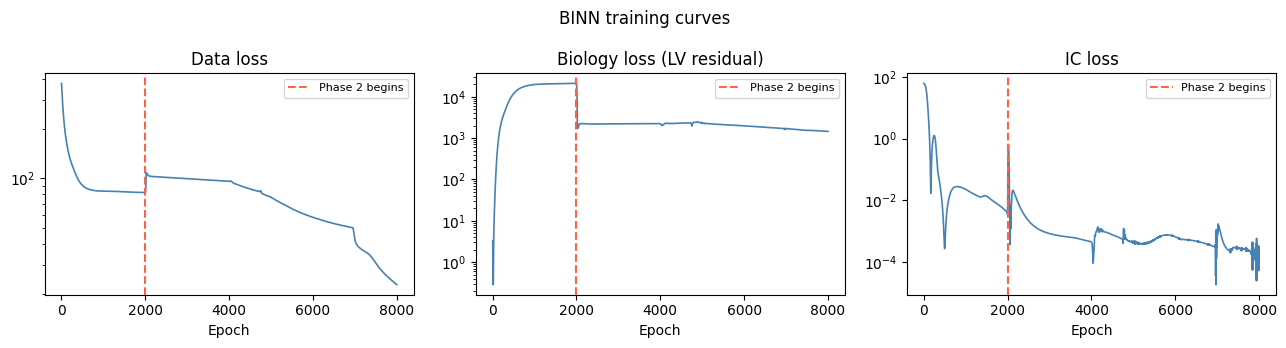

In [17]:
epochs = np.arange(1, PHASE1_EPOCHS + PHASE2_EPOCHS + 1)
phase_switch = PHASE1_EPOCHS

fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))

for ax, key, title in zip(axes,
                           ['data', 'bio', 'ic'],
                           ['Data loss', 'Biology loss (LV residual)', 'IC loss']):
    ax.semilogy(epochs, hist[key], lw=1.2, color='steelblue')
    ax.axvline(phase_switch, color='tomato', lw=1.5, ls='--', label='Phase 2 begins')
    ax.set(xlabel='Epoch', title=title)
    ax.legend(fontsize=8)

plt.suptitle('BINN training curves', fontsize=12)
plt.tight_layout(); plt.show()


## 5. Results


 Parameter   Recovered      True     Error
---------------------------------------------
     alpha      0.9994    1.0000      0.1%
      beta      0.2760    0.1000    176.0%
     gamma      0.2680    0.0750    257.3%
     delta      1.0409    1.5000     30.6%


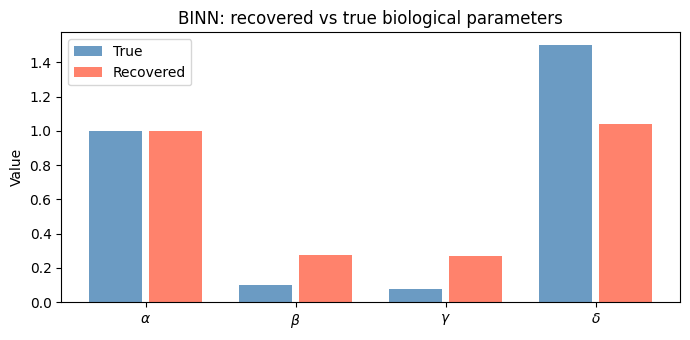

In [18]:
# ── Recovered vs true parameters ─────────────────────────────────────────────
params = {
    'alpha': (float(model.alpha), ALPHA_TRUE),
    'beta' : (float(model.beta),  BETA_TRUE),
    'gamma': (float(model.gamma), GAMMA_TRUE),
    'delta': (float(model.delta), DELTA_TRUE),
}

print(f"{'Parameter':>10}  {'Recovered':>10}  {'True':>8}  {'Error':>8}")
print('-' * 45)
for name, (rec, true) in params.items():
    err = abs(rec - true) / true * 100
    print(f'{name:>10}  {rec:>10.4f}  {true:>8.4f}  {err:>7.1f}%')

# ── Bar chart ─────────────────────────────────────────────────────────────────
labels = list(params.keys())
rec_vals  = [params[k][0] for k in labels]
true_vals = [params[k][1] for k in labels]

x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(x - 0.2, true_vals,  0.35, label='True',      color='steelblue', alpha=0.8)
ax.bar(x + 0.2, rec_vals,   0.35, label='Recovered',  color='tomato',    alpha=0.8)
ax.set(xticks=x, xticklabels=[f'$\\{l}$' for l in labels],
       ylabel='Value', title='BINN: recovered vs true biological parameters')
ax.legend(); plt.tight_layout(); plt.show()


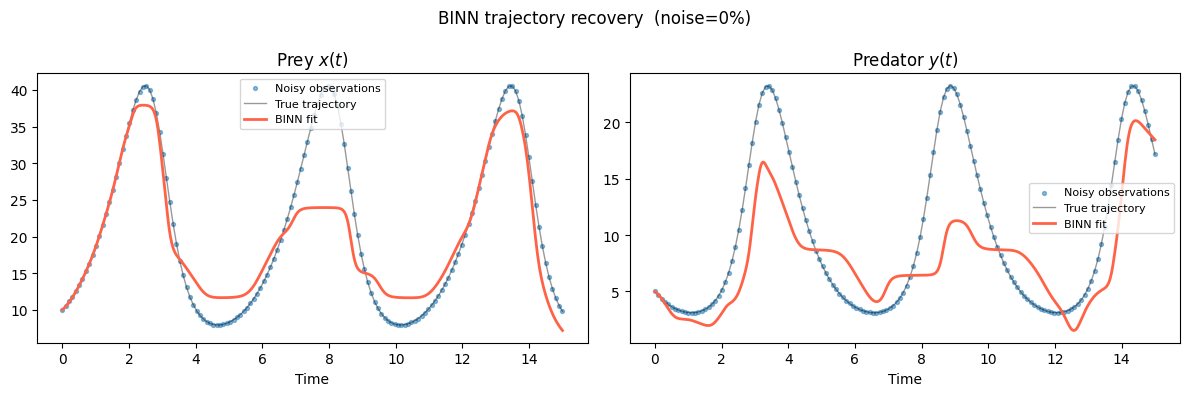

In [21]:
# ── Recovered trajectory ──────────────────────────────────────────────────────
t_dense = np.linspace(0, 15, 500).reshape(-1, 1).astype(np.float32)
xy_pred = model(tf.constant(t_dense)).numpy()
x_pred, y_pred = xy_pred[:, 0], xy_pred[:, 1]
t_dense_1d = t_dense[:, 0]                       # squeeze for plotting

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, label, x_tr, x_pr, x_ob in zip(
        axes,
        ['Prey $x(t)$', 'Predator $y(t)$'],
        [x_clean, y_clean],
        [x_pred,  y_pred],
        [x_data,  y_data]):
    ax.scatter(t_obs, x_ob, s=8, alpha=0.5, label='Noisy observations')
    ax.plot(t_obs, x_tr, 'k-',  lw=1, alpha=0.4, label='True trajectory')
    ax.plot(t_dense_1d, x_pr, 'tomato', lw=2, label='BINN fit')
    ax.set(xlabel='Time', title=label)
    ax.legend(fontsize=8)

plt.suptitle(f'BINN trajectory recovery  (noise={NOISE_LEVEL:.0%})', fontsize=12)
plt.tight_layout(); plt.show()


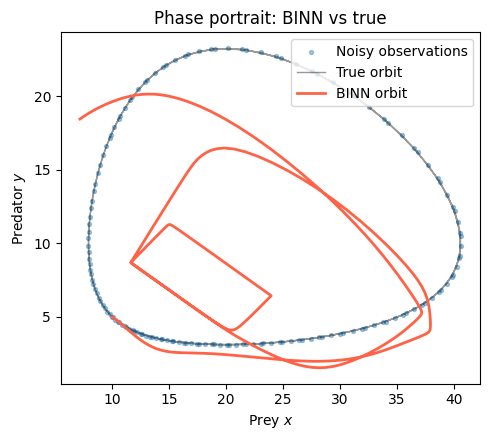

In [22]:
# ── Phase portrait (x vs y) ───────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4.5))
ax.scatter(x_data, y_data, s=8, alpha=0.4, label='Noisy observations')
ax.plot(x_clean, y_clean, 'k-', lw=1, alpha=0.4, label='True orbit')
ax.plot(x_pred,  y_pred,  'tomato', lw=2, label='BINN orbit')
ax.set(xlabel='Prey $x$', ylabel='Predator $y$',
       title='Phase portrait: BINN vs true')
ax.legend(); plt.tight_layout(); plt.show()


## 6. Discussion

### What the BINN learned

The network learned two things simultaneously:
- A smooth function $\mathcal{N}(t) \approx (x(t), y(t))$ that fits the noisy data.
- Four biological parameters $\hat{\alpha}, \hat{\beta}, \hat{\gamma}, \hat{\delta}$ that
  make the ODE residual small.

Neither could be learned without the other: without the biology loss, the network
has no reason to converge to the true parameters. Without the data, the parameters
are unidentifiable from the ODE alone (infinitely many solutions).

### Why automatic differentiation beats Savitzky-Golay

Commonly in SINDy, derivatives of the noisy data are estimated
numerically using Savitzky-Golay smoothing. This works at low noise but saturates.

The BINN never differentiates the *data*. Instead it differentiates the *network*:
$$\frac{d}{dt}\mathcal{N}_\theta(t) = \text{exact, via chain rule through the network}$$
This derivative is smooth and noise-free — it's a property of the learned function,
not of the data. The noise in the data enters only through the data loss term.

### Limitations

- **You must know the equation structure.** If you don't know it's Lotka-Volterra,
  BINNs cannot discover this for you. (That's what methods like SINDy and DSO are for.)
- **Collocation point placement matters.** Too few collocation points and the physics
  is under-enforced in parts of the domain.
- **Physics weight $\lambda_{\text{bio}}$ needs tuning.** Too high and the network ignores
  data; too low and the parameters don't converge.
- **Training can be sensitive to initialisation** — a common challenge with PINNs.

### Exercises
1. Set `NOISE_LEVEL = 0.30` and re-run. Does the BINN still recover the parameters?
   Compare to what happens with SINDy at this noise level.
2. Mis-specify the model: remove the $xy$ term from $\dot{y}$ (use $-\delta y$ only).
   What happens to the trajectory fit and the parameters?
3. Change `LAM_BIO` from 0.01 to 0.001 or 0.1. How does this affect parameter recovery?
4. What happens if you skip Phase 1 entirely (start with physics from epoch 1)?


---
## 7. Connection to the Tutorial

BINNs sit at the intersection of two ideas from this tutorial:

| | Logistic regression (Pt 1) | BINN (this notebook) |
|---|---|---|
| Model class | Known (linear) | Known (LV equations) |
| Parameters | Fit by MLE / gradient descent | Fit by gradient descent |
| Output | Coefficients $w_k$ | Parameters $\alpha, \beta, \gamma, \delta$ |
| Interpretability | Read off the weights | Read off the biology |

The difference is that Part 1 used a *statistical* model you could write down analytically.
Here the model is a *mechanistic ODE* — and the neural network is used not for prediction
but as a smooth surrogate for the unknown solution.

**The key shift**: in deep learning, interpretability doesn't have to mean
'inspect the network weights.' It can mean 'use the network as a tool to extract
something you already cared about' — in this case, biological rate parameters.

### Further reading
- Lagergren et al. (2020). *Biologically-informed neural networks guide mechanistic
  modeling from sparse experimental data.* PLOS Computational Biology.
  [[paper]](https://doi.org/10.1371/journal.pcbi.1008462)
- Raissi, Perdikaris & Karniadakis (2019). *Physics-informed neural networks.*
  Journal of Computational Physics. [[paper]](https://doi.org/10.1016/j.jcp.2018.10.045)
- Brunton & Kutz (2022). *Data-Driven Science and Engineering.* Cambridge.
  (Covers SINDy, PINNs, and equation learning in a unified framework.)


---
## 8. Real Data: Hudson Bay Lynx-Hare (1900–1920)

The Lotka-Volterra model was inspired by exactly this system.
The Hudson Bay Company recorded annual fur-trade pelt counts for both
Canadian lynx and snowshoe hare from the 1840s to the 1930s.

We use the classic 1900–1920 window (Leigh 1968; reproduced in Murray 2002
*Mathematical Biology*) — two full oscillation cycles, 21 annual observations.

**A few things to watch for:**
- Pelt counts are a proxy for population, not direct census data — expect noise.
- The hare population can cycle independently of lynx (food/vegetation effects), so LV is an approximation.
- The BINN will still recover biologically meaningful parameters and the fit
  will be good — the residual tells you *where* the approximation breaks down.

The recovered parameters (in units of 1/year and 1/(thousands·year)) will be
different from the synthetic example because the population scale is different.

Loaded 21 observations (1900-1920)
Hare mean=34.1k,  Lynx mean=20.2k
   year  hare_thousands  lynx_thousands
0  1900            30.0             4.0
1  1901            47.2             6.1
2  1902            70.2             9.8
3  1903            77.4            35.2
4  1904            36.3            59.4


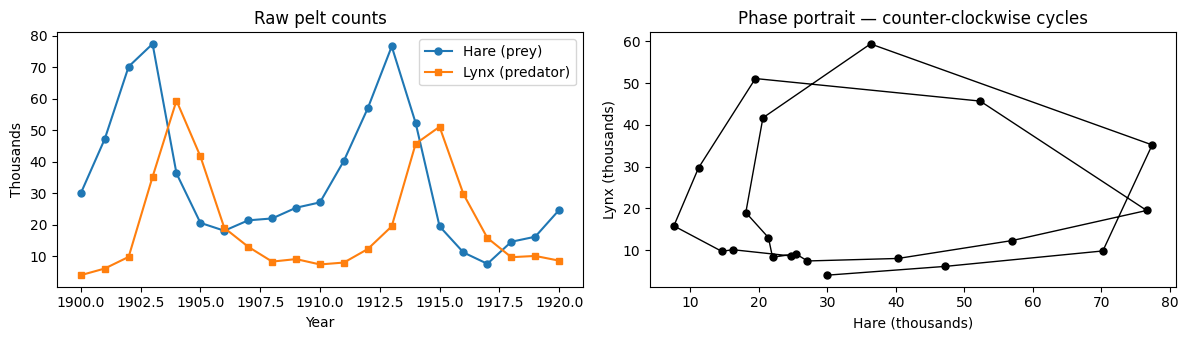

In [23]:
# ── Load Hudson Bay lynx-hare data ────────────────────────────────────────────
# Source: Leigh (1968) / Murray (2002) Mathematical Biology.
# Annual pelt counts in thousands, 1900-1920.  File: data/lynx_hare.csv
#
# Note: statsmodels.datasets.lynx has a longer lynx-only series (1821-1934).
# For *both* species together, load from the repo CSV below.
import pandas as pd, os

# Works whether running locally (cloned repo) or in Colab (mounted Drive).
csv_path = 'data/lynx_hare.csv'
df = pd.read_csv(csv_path)

years     = df['year'].values
hare_raw  = df['hare_thousands'].values.astype(float)
lynx_raw  = df['lynx_thousands'].values.astype(float)

# Normalise to unit-mean so populations are O(1) — keeps LV parameters
# in a sensible range and makes training comparable to the synthetic example
hare_mean = hare_raw.mean()
lynx_mean = lynx_raw.mean()
hare_obs  = hare_raw / hare_mean
lynx_obs  = lynx_raw / lynx_mean
t_real    = (years - 1900).astype(np.float32)   # time 0..20 years

print(f'Loaded {len(df)} observations (1900-1920)')
print(f'Hare mean={hare_mean:.1f}k,  Lynx mean={lynx_mean:.1f}k')
print(df.head())

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].plot(years, hare_raw, 'C0o-', ms=5, label='Hare (prey)')
axes[0].plot(years, lynx_raw, 'C1s-', ms=5, label='Lynx (predator)')
axes[0].set(xlabel='Year', ylabel='Thousands', title='Raw pelt counts')
axes[0].legend()
axes[1].plot(hare_raw, lynx_raw, 'ko-', ms=5, lw=1)
axes[1].set(xlabel='Hare (thousands)', ylabel='Lynx (thousands)',
            title='Phase portrait — counter-clockwise cycles')
plt.tight_layout(); plt.show()


In [24]:
# ── Prepare tensors for real data ─────────────────────────────────────────────
t_real_tf    = tf.constant(t_real.reshape(-1, 1),              dtype=tf.float32)
xy_real_tf   = tf.constant(np.column_stack([hare_obs, lynx_obs]), dtype=tf.float32)
ic_real_tf   = tf.constant([[hare_obs[0], lynx_obs[0]]], dtype=tf.float32)

N_COLLOC_R   = 400
t_colloc_r   = np.linspace(0, 20, N_COLLOC_R).reshape(-1, 1).astype(np.float32)

def train_step_real(model, opt_net, opt_bio, lam_bio, lam_ic):
    with tf.GradientTape() as outer:
        xy_pred   = model(t_real_tf)
        data_loss = tf.reduce_mean(tf.square(xy_pred - xy_real_tf))
        xy_ic     = model(tf.constant([[0.0]]))
        ic_loss   = tf.reduce_mean(tf.square(xy_ic - ic_real_tf))
        with tf.GradientTape(persistent=True) as inner:
            t_c  = tf.constant(t_colloc_r)
            inner.watch(t_c)
            xy_c = model(t_c)
            x_c, y_c = xy_c[:, 0:1], xy_c[:, 1:2]
        dxdt = inner.gradient(x_c, t_c)
        dydt = inner.gradient(y_c, t_c)
        del inner
        res_x    = dxdt - (model.alpha * x_c - model.beta  * x_c * y_c)
        res_y    = dydt - (model.gamma * x_c * y_c - model.delta * y_c)
        bio_loss = tf.reduce_mean(tf.square(res_x)) + tf.reduce_mean(tf.square(res_y))
        total    = data_loss + lam_bio * bio_loss + lam_ic * ic_loss
    net_vars  = [v for v in model.trainable_variables if 'log_' not in v.name]
    bio_vars  = [v for v in model.trainable_variables if 'log_' in v.name]
    all_vars  = net_vars + bio_vars
    all_grads = outer.gradient(total, all_vars)
    opt_net.apply_gradients(zip(all_grads[:len(net_vars)], net_vars))
    opt_bio.apply_gradients(zip(all_grads[len(net_vars):], bio_vars))
    return float(data_loss), float(bio_loss), float(ic_loss)

# ── Fresh model + training ─────────────────────────────────────────────────────
real_model   = LotkaVolterraBINN(hidden_units=32, n_layers=3)
real_opt_net = tf.keras.optimizers.Adam(5e-4)
real_opt_bio = tf.keras.optimizers.Adam(5e-5)
hist_r = {'data': [], 'bio': [], 'ic': []}

P1, P2      = 2000, 6000
LAM_BIO_R   = 0.005
LAM_IC_R    = 2.0
PRINT_EVERY_R = 1000

print(f'Phase 1/2 — trajectory fit only  ({P1} epochs)')
print(f'{"Epoch":>10}  {"data_loss":>10}  {"ic_loss":>9}')
print('─' * 35)
for ep in range(1, P1 + 1):
    dl, bl, il = train_step_real(real_model, real_opt_net, real_opt_bio, 0.0, LAM_IC_R)
    hist_r['data'].append(dl); hist_r['bio'].append(bl); hist_r['ic'].append(il)
    if ep % PRINT_EVERY_R == 0:
        print(f'{ep:>5}/{P1}  {dl:>10.5f}  {il:>9.5f}')

print(f'\nPhase 2/2 — data + biology  ({P2} epochs,  λ_bio={LAM_BIO_R})')
print(f'{"Epoch":>10}  {"data":>8}  {"bio":>8}  {"ic":>6}  {"α":>7}  {"β":>7}  {"γ":>7}  {"δ":>7}')
print('─' * 72)
for ep in range(1, P2 + 1):
    dl, bl, il = train_step_real(real_model, real_opt_net, real_opt_bio, LAM_BIO_R, LAM_IC_R)
    hist_r['data'].append(dl); hist_r['bio'].append(bl); hist_r['ic'].append(il)
    if ep % PRINT_EVERY_R == 0:
        a, b, g, d = float(real_model.alpha), float(real_model.beta), float(real_model.gamma), float(real_model.delta)
        print(f'{ep:>5}/{P2}  {dl:>8.5f}  {bl:>8.5f}  {il:>6.5f}  {a:>7.4f}  {b:>7.4f}  {g:>7.4f}  {d:>7.4f}')

print(f'\nDone.  Recovered:  α={float(real_model.alpha):.4f}  β={float(real_model.beta):.4f}'
      f'  γ={float(real_model.gamma):.4f}  δ={float(real_model.delta):.4f}')


Phase 1/2 — trajectory fit only  (2000 epochs)
     Epoch   data_loss    ic_loss
───────────────────────────────────
 1000/2000     0.36769    0.00002
 2000/2000     0.12381    0.00000

Phase 2/2 — data + biology  (6000 epochs,  λ_bio=0.005)
     Epoch      data       bio      ic        α        β        γ        δ
────────────────────────────────────────────────────────────────────────
 1000/6000   0.00748   0.09902  0.00000   0.5336   0.4950   0.5536   0.5554
 2000/6000   0.00169   0.10268  0.00000   0.5668   0.5286   0.5921   0.5882
 3000/6000   0.00108   0.09961  0.00000   0.5899   0.5489   0.6247   0.6208
 4000/6000   0.00094   0.09107  0.00000   0.6032   0.5608   0.6552   0.6535
 5000/6000   0.00083   0.08417  0.00000   0.6089   0.5661   0.6857   0.6867
 6000/6000   0.00075   0.07828  0.00000   0.6105   0.5676   0.7163   0.7208

Done.  Recovered:  α=0.6105  β=0.5676  γ=0.7163  δ=0.7208


In [ ]:
# ── Recovered parameters ──────────────────────────────────────────────────────
print('Recovered Lotka-Volterra parameters (populations normalised to unit-mean):')
print(f'  alpha (hare growth rate)    = {float(real_model.alpha):.4f} /yr')
print(f'  beta  (predation rate)      = {float(real_model.beta):.4f}  /yr per (normalised unit)')
print(f'  gamma (conversion rate)     = {float(real_model.gamma):.4f} /yr per (normalised unit)')
print(f'  delta (lynx death rate)     = {float(real_model.delta):.4f} /yr')
print()
print('Literature estimates for lynx-hare (Stenseth et al. 1997; Sheldon 2019):')
print('  alpha ~0.4-0.8 /yr   beta ~0.005-0.05   gamma ~0.005-0.05   delta ~0.3-1.0 /yr')

# ── Trajectory ────────────────────────────────────────────────────────────────
t_fine = np.linspace(0, 20, 500).reshape(-1, 1).astype(np.float32)
xy_fit = real_model(tf.constant(t_fine)).numpy()
t_fine_1d = t_fine[:, 0]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ax = axes[0]
ax.scatter(t_real, hare_obs, s=30, c='C0', zorder=5, label='Hare (normalised)')
ax.scatter(t_real, lynx_obs, s=30, c='C1', marker='s', zorder=5, label='Lynx (normalised)')
ax.plot(t_fine_1d, xy_fit[:, 0], 'C0-', lw=2, alpha=0.8)
ax.plot(t_fine_1d, xy_fit[:, 1], 'C1-', lw=2, alpha=0.8)
ax.set(xlabel='Time (years)', ylabel='Population / mean',
       title='BINN fit to lynx-hare data')
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(hare_obs, lynx_obs, 'ko-', ms=6, lw=1, label='Data (1900–1920)', zorder=5)
ax.plot(xy_fit[:, 0], xy_fit[:, 1], 'tomato', lw=2, label='BINN orbit')
ax.set(xlabel='Hare', ylabel='Lynx', title='Phase portrait')
ax.legend(fontsize=9)

plt.suptitle('BINN applied to real Hudson Bay data', fontsize=12)
plt.tight_layout(); plt.show()

# ── Training curves ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
all_ep = np.arange(1, P1 + P2 + 1)
for ax, key, title in zip(axes,
                           ['data','bio','ic'],
                           ['Data loss','Biology loss','IC loss']):
    ax.semilogy(all_ep, hist_r[key], lw=1.2, color='steelblue')
    ax.axvline(P1, color='tomato', lw=1.5, ls='--', label='Phase 2')
    ax.set(xlabel='Epoch', title=title); ax.legend(fontsize=8)
plt.suptitle('Training curves — real data', fontsize=11)
plt.tight_layout(); plt.show()

### What to look for

**If the fit is good** (data loss low, phase portrait loops match):
the Lotka-Volterra model is a reasonable description of this system
and the recovered parameters are interpretable as biological rates.

**If the biology loss plateaus high** (not converging to near-zero
even as data loss falls):
the ODE residual is telling you that no choice of constant LV parameters
can simultaneously fit all time points — a signal of model mis-specification.
Possible causes: pelt counts ≠ populations, hare food limitation, time-varying
parameters, or climate-driven forcing.

**Comparing to literature**: The recovered $\alpha$ should be near the
hare's intrinsic growth rate (~0.5–0.8 /yr). The ratio $\delta/\gamma$
gives the prey population at the predator–prey coexistence equilibrium.

> This is BINNs in practice: you bring the equation *structure*,
> the network and gradient descent find the *parameters*,
> and the residuals tell you whether the structure was right.
